# EDA_MultiForces_Street
Exploratory Data Analysis (EDA) for UK Police **Street Crime Data (2023–2024)**

This notebook focuses on finding insights first and visualising.
If you followd my preprocessing sheet then the file you will be looking for in this sheet will be saved as multi-forces-2023-2024_street_clean.csv'

In [1]:
# --- 1. Setup & Load ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import geopandas as gpd
from pathlib import Path

BASE_PATH = r"C:\Users\micha\Documents\PyData_Project"
file_path = os.path.join(BASE_PATH, 'data', 'preprocessed', 'multi-forces-2023-2024_street_clean.csv')

df = pd.read_csv(file_path)
print(" Data loaded successfully!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

 Data loaded successfully!
Shape: (2987253, 10)
Columns: ['crime_id', 'month', 'reported_by', 'longitude', 'latitude', 'location', 'lsoa_code', 'lsoa_name', 'crime_type', 'last_outcome_category']


## 1. Overview & Quality Checks

In [2]:
print("--- INFO ---")
df.info()

print("Missing Values ")
print((df.isna().mean()*100).round(2).sort_values(ascending=False).head(10))

if 'crime_id' in df.columns:
    print("\nDuplicate crime_id count:", df['crime_id'].duplicated().sum())

if 'month' in df.columns:
    df['month'] = pd.to_datetime(df['month'], errors='coerce')
    print("\nDate Range:", df['month'].min(), 'to', df['month'].max())



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2987253 entries, 0 to 2987252
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   crime_id               object 
 1   month                  object 
 2   reported_by            object 
 3   longitude              float64
 4   latitude               float64
 5   location               object 
 6   lsoa_code              object 
 7   lsoa_name              object 
 8   crime_type             object 
 9   last_outcome_category  object 
dtypes: float64(2), object(8)
memory usage: 227.9+ MB
Missing Values 
crime_id                 10.15
last_outcome_category    10.15
lsoa_name                 1.09
longitude                 1.09
lsoa_code                 1.09
latitude                  1.09
month                     0.00
reported_by               0.00
location                  0.00
crime_type                0.00
dtype: float64

Duplicate crime_id count: 339762

Date Range: 

## 2. Regional Crime Comparison (by Force)

In [3]:
if 'reported_by' in df.columns:
    force_counts = df['reported_by'].value_counts().sort_values(ascending=False)
    print("Records per Police Force ")
    print(force_counts)

    force_pct = (force_counts / force_counts.sum() * 100).round(2)
    print("\n--- Percentage share of crimes per Force ---")
    print(force_pct)

Records per Police Force 
reported_by
Metropolitan Police Service    2059934
West Midlands Police            694828
Leicestershire Police           213456
City of London Police            19035
Name: count, dtype: int64

--- Percentage share of crimes per Force ---
reported_by
Metropolitan Police Service    68.96
West Midlands Police           23.26
Leicestershire Police           7.15
City of London Police           0.64
Name: count, dtype: float64


## 3. Crime Type Analysis

In [4]:
if 'crime_type' in df.columns:
    type_counts = df['crime_type'].value_counts()
    print(" Top 10 Crime Types ")
    print(type_counts.head(10))

    print("--- Least Common Crime Types ---")
    print(type_counts.tail(5))

 

 Top 10 Crime Types 
crime_type
Violence and sexual offences    882482
Other theft                     314763
Anti-social behaviour           303209
Vehicle crime                   283562
Shoplifting                     211551
Criminal damage and arson       186455
Theft from the person           181817
Public order                    180412
Burglary                        156929
Drugs                            97806
Name: count, dtype: int64
--- Least Common Crime Types ---
crime_type
Drugs                    97806
Robbery                  84134
Other crime              40384
Bicycle theft            39010
Possession of weapons    24739
Name: count, dtype: int64


## 4. Time Trends (Monthly / Seasonal)

In [5]:
if 'month' in df.columns:
    monthly_counts = df.groupby(df['month'].dt.to_period('M')).size().reset_index(name='count')
    print("\n--- Monthly Totals (first 12 shown) ---")
    print(monthly_counts.head(12))

    yearly_counts = df.groupby(df['month'].dt.year).size()
    print("\n--- Crimes per Year ---")
    print(yearly_counts)


--- Monthly Totals (first 12 shown) ---
      month   count
0   2023-01  120424
1   2023-02  115229
2   2023-03  127377
3   2023-04  120283
4   2023-05  127222
5   2023-06  136337
6   2023-07  130007
7   2023-08  123775
8   2023-09  124986
9   2023-10  133089
10  2023-11  125271
11  2023-12  122206

--- Crimes per Year ---
month
2023    1506206
2024    1481047
dtype: int64


## 5. Spatial Hotspots (by Location / LSOA)

In [6]:
if 'lsoa_name' in df.columns:
    top_lsoa = df['lsoa_name'].value_counts().head(10)
    print("\n--- Top 10 LSOAs by Crime Volume ---")
    print(top_lsoa)

    low_lsoa = df['lsoa_name'].value_counts().tail(10)
    print("\n--- 10 Safest (Least Crime) LSOAs ---")
    print(low_lsoa)


--- Top 10 LSOAs by Crime Volume ---
lsoa_name
Westminster 013G       26437
Westminster 013B       22803
Westminster 018A       22046
City of London 001F    13676
Westminster 018C       12292
Birmingham 138A        10667
Hillingdon 031A         8401
Leicester 041E          8265
Westminster 011B        8029
Westminster 018B        7410
Name: count, dtype: int64

--- 10 Safest (Least Crime) LSOAs ---
lsoa_name
Trafford 004D                 1
Torridge 008A                 1
Tonbridge and Malling 012E    1
Thurrock 001B                 1
Teignbridge 015A              1
Tandridge 006C                1
Tandridge 004A                1
Swansea 016B                  1
Surrey Heath 005B             1
Stoke-on-Trent 024B           1
Name: count, dtype: int64


## 6.Comparisons

In [6]:

    top_forces = df['reported_by'].value_counts().nlargest(2).index
    subset = df[df['reported_by'].isin(top_forces)]
    comp = subset.groupby(['reported_by','crime_type']).size().unstack()
    print("--- Crime Type Comparison: Top 2 Forces ---")
    print(comp.head(10))

--- Crime Type Comparison: Top 2 Forces ---
crime_type                   Anti-social behaviour  Bicycle theft  Burglary  \
reported_by                                                                   
Metropolitan Police Service                 247070          31597    108613   
West Midlands Police                         40417           4216     37422   

crime_type                   Criminal damage and arson  Drugs  Other crime  \
reported_by                                                                  
Metropolitan Police Service                     112674  74663        22127   
West Midlands Police                             53093  15524        12990   

crime_type                   Other theft  Possession of weapons  Public order  \
reported_by                                                                     
Metropolitan Police Service       246717                   9465        112090   
West Midlands Police               46847                  13136         44889   

c

Next I will compare leicestershire to metroplitan (I might choose to focus on these 2 urban vs suburban?)

In [7]:
selcted_forces = ['Metropolitan Police Service', 'Leicestershire Police']
sub = df[df['reported_by'].isin(selcted_forces)]
comparison =sub.groupby(['reported_by','crime_type']).size().unstack()
print("--- Crime Type Comparison: Metropolitan vs Leicestershire ---")
print(comparison.head(10))

--- Crime Type Comparison: Metropolitan vs Leicestershire ---
crime_type                   Anti-social behaviour  Bicycle theft  Burglary  \
reported_by                                                                   
Leicestershire Police                        15190           2734     10225   
Metropolitan Police Service                 247070          31597    108613   

crime_type                   Criminal damage and arson  Drugs  Other crime  \
reported_by                                                                  
Leicestershire Police                            19969   6467         4889   
Metropolitan Police Service                     112674  74663        22127   

crime_type                   Other theft  Possession of weapons  Public order  \
reported_by                                                                     
Leicestershire Police              16991                   1967         22136   
Metropolitan Police Service       246717                   9465  

## 7. Summary Insights (Textual)


### Summary Ideas ###
- Which force reports most and least crimes.
- Top 3 crime types across all forces.
- Monthly patterns (e.g., summer peaks).
- Which LSOAs/areas show highest and lowest activity.
- Identify two forces for deeper analysis phase.


## 8. Visualisations 

## Crimes by Force

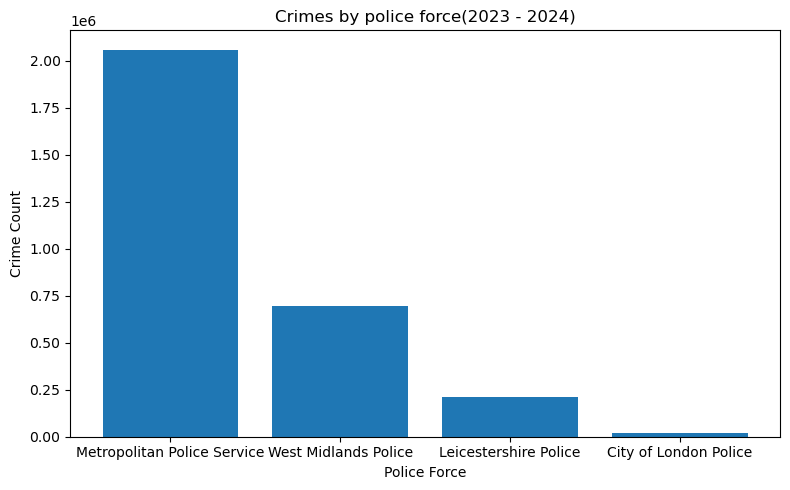

reported_by
Metropolitan Police Service    2059934
West Midlands Police            694828
Leicestershire Police           213456
City of London Police            19035
Name: count, dtype: int64
reported_by
Metropolitan Police Service    1776692
West Midlands Police            654411
Leicestershire Police           198266
City of London Police            18121
Name: crime_id, dtype: int64


In [37]:


num_forces= np.arange(len(df['reported_by'].value_counts()))


plt.figure(figsize=(8, 5))
plt.bar(num_forces,df['reported_by'].value_counts())
plt.ylabel('Crime Count')
plt.xlabel('Police Force')
plt.xticks(num_forces,df['reported_by'].value_counts().index)
plt.title('Crimes by police force(2023 - 2024)')
plt.tight_layout()
plt.show()




## Top 10 Crime Types

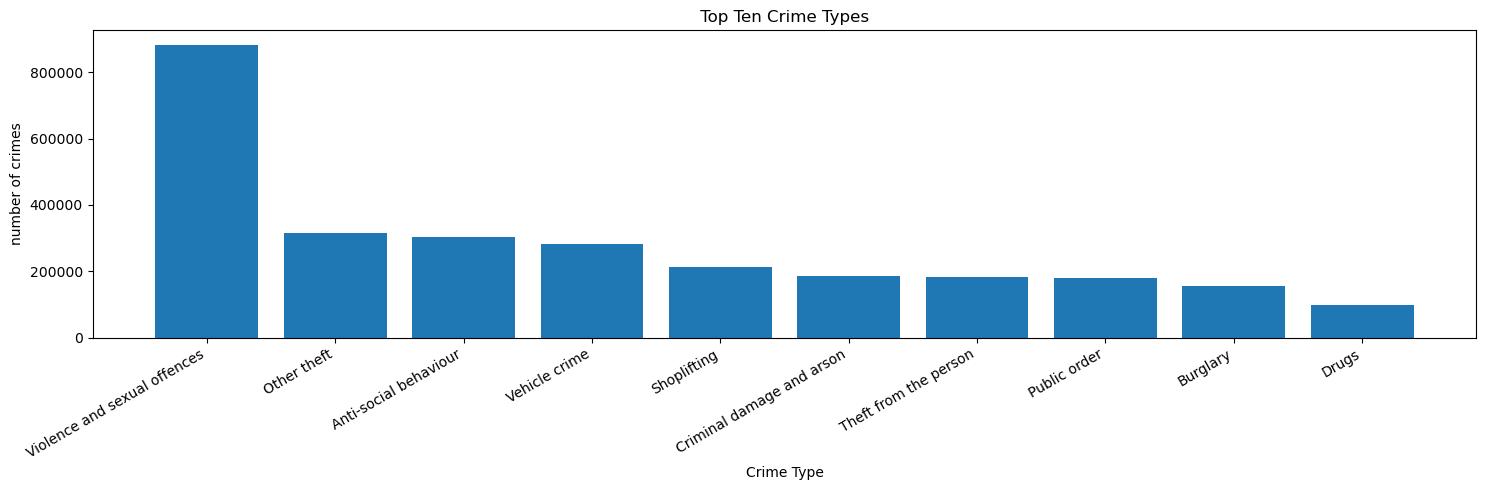

In [6]:
top_types =df['crime_type'].value_counts().head(10)
num_type = np.arange(len(top_types))
plt.figure(figsize=(15, 5))
plt.bar(num_type,top_types.values)
plt.ylabel('number of crimes')
plt.xlabel('Crime Type')
plt.xticks(num_type,top_types.index,rotation = 30, ha='right')
plt.title(' Top Ten Crime Types ')
plt.tight_layout()
plt.show()

In [20]:
print(df['reported_by'].unique())

['City of London Police' 'Leicestershire Police'
 'Metropolitan Police Service' 'West Midlands Police']


## Trend in crime over the months (2023 2024)

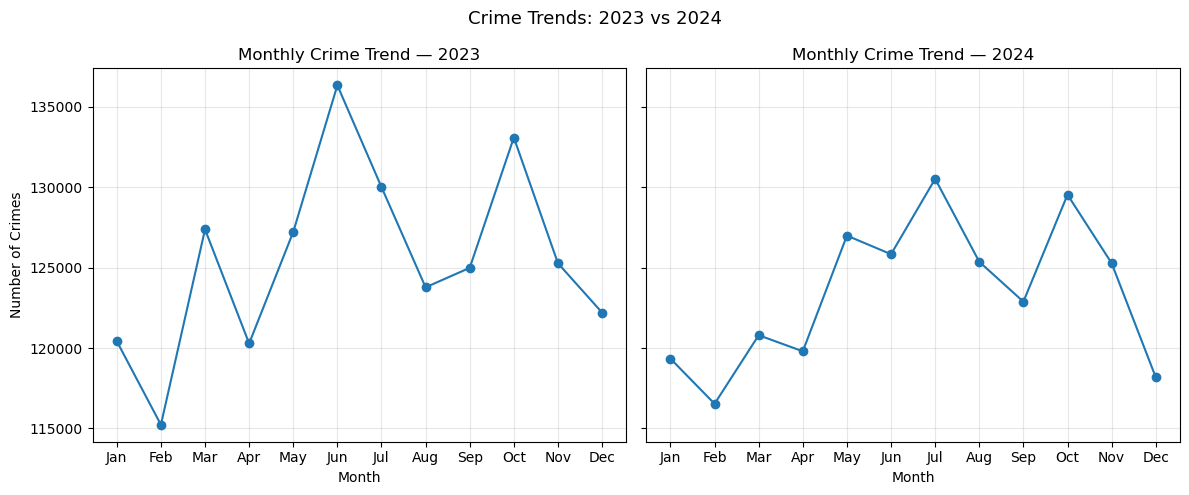

In [10]:
years = sorted(monthly['year'].unique())

# Create 1 row × 2 columns so both charts can be side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, yr in enumerate(years):
    sub = monthly[monthly['year'] == yr]

    axes[i].plot(sub['month_num'], sub['count'], marker='o', color='tab:blue')
    axes[i].set_title(f"Monthly Crime Trend — {yr}")
    axes[i].set_xlabel("Month")
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    axes[i].grid(alpha=0.3)


axes[0].set_ylabel("Number of Crimes")
fig.suptitle("Crime Trends: 2023 vs 2024", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
Crime Percentage by Region

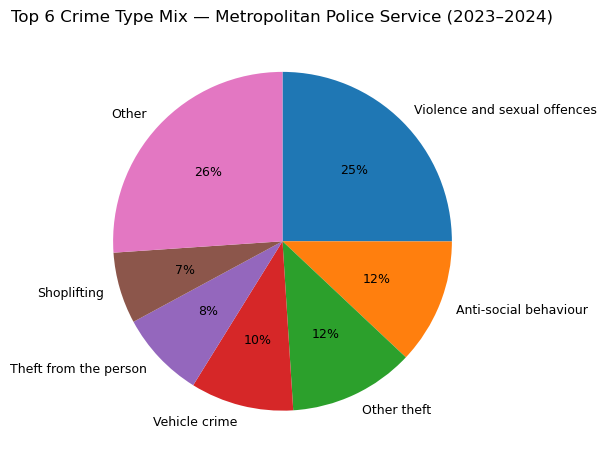

In [14]:
region = "Metropolitan Police Service"   # you can change this line for each force

# Filter data for that region
sub = df[df['reported_by'] == region].copy()

# Count crime types and normalise to percentages
crime_type_counts = sub['crime_type'].value_counts(normalize=True)

#  Keep top 6 and group the rest as 'Other'
top_n = 6
if len(crime_type_counts) > top_n:
    top = crime_type_counts.head(top_n)
    other = pd.Series({'Other': crime_type_counts.iloc[top_n:].sum()})
    crime_type_counts = pd.concat([top, other])
crime_type_counts = crime_type_counts * 100  # convert to %

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    crime_type_counts,
    labels=crime_type_counts.index,
    autopct='%1.0f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 9}
)
plt.title(f"Top 6 Crime Type Mix — {region} (2023–2024)", fontsize=12)
plt.tight_layout()
plt.show()

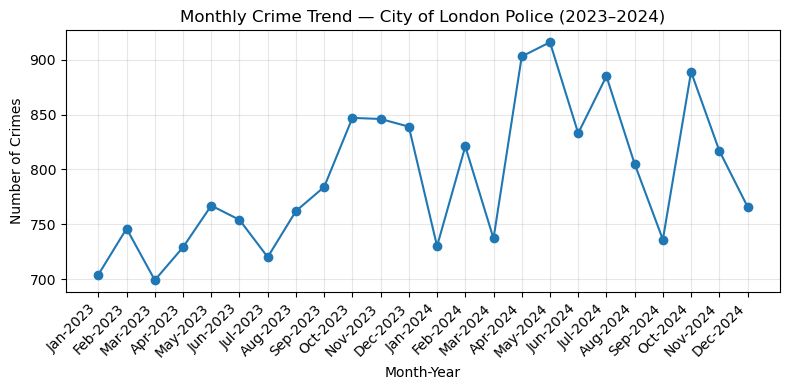

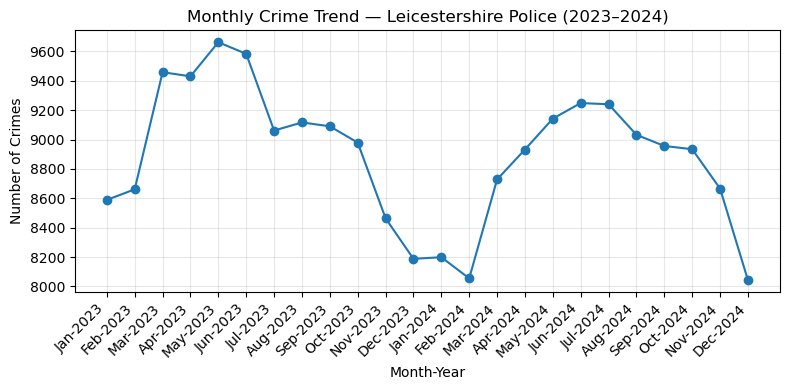

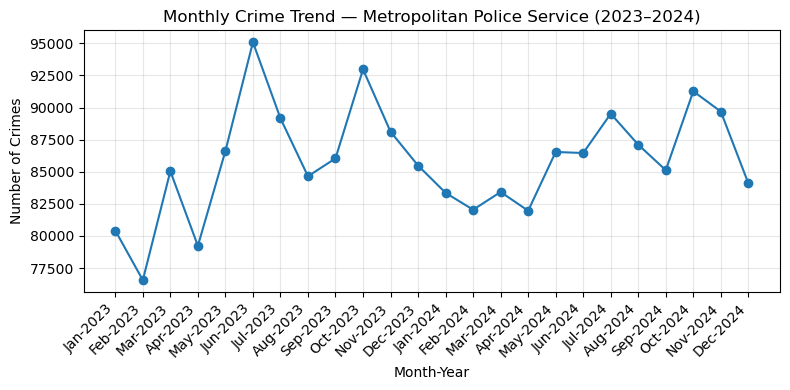

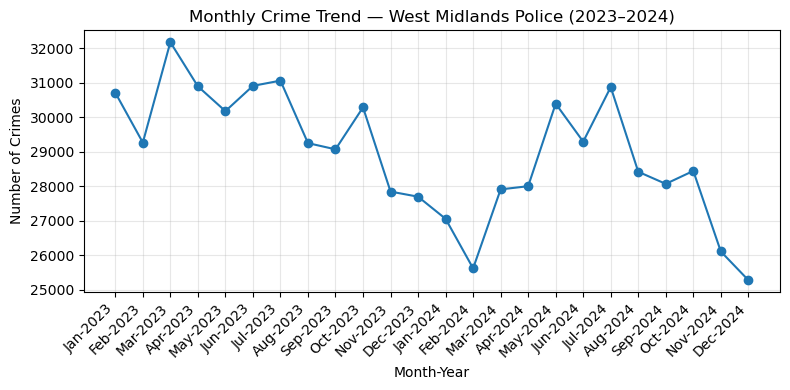

In [20]:
forces_s = trend['reported_by'].unique()

for force in forces_s :
    sub = trend[trend['reported_by'] == force]
    x_labels = [f"{m}-{y}" for y, m in zip(sub['year'], sub['month_name'])]

    plt.figure(figsize=(8,4))
    plt.plot(
        x_labels,
        sub['crime_count'],
        marker='o',
        color='tab:blue'
    )
    plt.title(f"Monthly Crime Trend — {force} (2023–2024)")
    plt.xlabel("Month-Year")
    plt.ylabel("Number of Crimes")
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


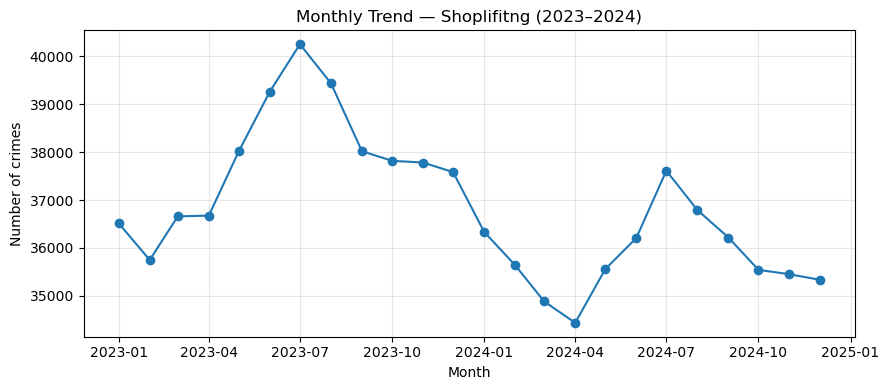

In [29]:
CRIME = "Shoplifitng"   # pick any crime_type
                             

# Build monthly series for that type (2023–2024)
s = (df[df['crime_type'] == CRIME]
       .groupby(df['month'].dt.to_period('M'))
       .size()
       .rename('count'))
s.index = s.index.to_timestamp()




import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
plt.plot(s_plot.index, s_plot.values, marker='o')
plt.title(f"Monthly Trend — {CRIME} (2023–2024)")
plt.xlabel("Month"); plt.ylabel("Number of crimes")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

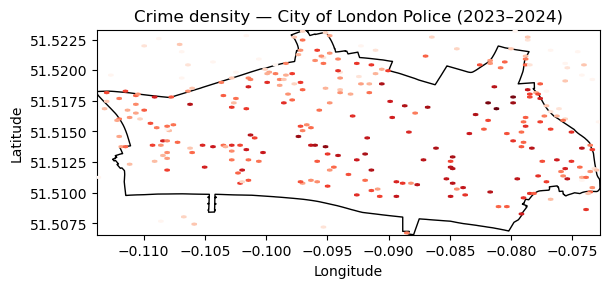

In [39]:
# --- choose force 
force_name = "City of London Police"  
# 'City of London Police' 'Leicestershire Police' 'Metropolitan Police Service' 'West Midlands Police' copy and paste into forc_name
# --- load boundary (
BOUND_DIR = Path(r"C:\Users\micha\Documents\PyData_Project\data\force kmls")
force_to_file = {
    "Metropolitan Police Service": "metropolitan.kml",
    "Leicestershire Police": "leicestershire.kml",
    "City of London Police": "city-of-london.kml",
    "West Midlands Police": "west-midlands.kml"
}
boundary = gpd.read_file(BOUND_DIR / force_to_file[force_name], driver="KML")
boundary = boundary.to_crs(epsg=4326)

# --- use boundary bbox to select only nearby points 
minx, miny, maxx, maxy = boundary.total_bounds


sub = df[df["reported_by"] == force_name].copy()
sub = sub.dropna(subset=["longitude","latitude"])

if sub["longitude"].min() < minx - 1 or sub["longitude"].max() > maxx + 1:
    sub = df.dropna(subset=["longitude","latitude"]).copy()


sub = sub[
    sub["longitude"].between(minx, maxx) &
    sub["latitude"].between(miny, maxy)
]

# --- plot boundary
plt.figure(figsize=(6.2,6.2))

# draw boundary first (outline only)
boundary.plot(ax=plt.gca(), color="none", edgecolor="black", linewidth=1, zorder=2)


hb = plt.hexbin(
    sub["longitude"], sub["latitude"],
    gridsize=120, mincnt=1, cmap="Reds",
    norm=LogNorm(),
    zorder=3
)

#plt.colorbar(hb, label="Crimes per hex (log scale)")
plt.title(f"Crime density — {force_name} (2023–2024)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")


plt.xlim(minx, maxx)
plt.ylim(miny, maxy)
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()